In [7]:
import numpy as np
import pandas as pd

import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [355]:
# get KRW price data and compute returns
ticker_list = ['KRW=X', 'JPYKRW=X', 'AUDKRW=X', 'CHFKRW=X']
label_list = ['KRW/USD', 'KRW/JPY', 'AUD/KRW', 'KRW/CHF']

fx_krw_prices = yf.download(ticker_list, interval='1d', period='max')['Close']
fx_krw_prices = fx_krw_prices.rename(columns=dict(zip(ticker_list, label_list))).dropna(how='any', axis=0)
fx_krw_returns = fx_krw_prices.pct_change().iloc[1:]

# add columsn: EQW PF return, year, obs per year
fx_krw_returns['eqwpf'] = fx_krw_returns[label_list].mean(axis=1)
fx_krw_returns['Year'] = pd.to_datetime(fx_krw_returns.reset_index().Date).dt.strftime("%Y").values
fx_krw_returns['obs'] = fx_krw_returns.groupby(['Year']).transform('count').mean(axis=1).values


invest_cols = label_list + ['eqwpf']
# annualized returns
fx_krw_returns_ann = fx_krw_returns[invest_cols] * 360 #.mul(fx_krw_returns['obs'], axis=0)
# portfolio index
fx_krw_indices = (1+fx_krw_returns[invest_cols]).cumprod() * 100

display(fx_krw_returns[invest_cols].describe())

[*********************100%***********************]  4 of 4 completed


Ticker,KRW/USD,KRW/JPY,AUD/KRW,KRW/CHF,eqwpf
count,5911.000000,5911.000000,5911.000000,5911.000000,5911.000000
mean,0.000061,0.000018,0.000068,0.000152,0.000075
std,0.008586,0.010526,0.009673,0.010009,0.008445
min,-0.096243,-0.107550,-0.107342,-0.101553,-0.100900
25%,-0.003521,-0.004740,-0.004021,-0.004126,-0.003296
50%,0.000000,-0.000200,0.000134,0.000165,0.000016
75%,0.003621,0.004343,0.004210,0.004294,0.003423
max,0.090698,0.109904,0.138124,0.185269,0.098491


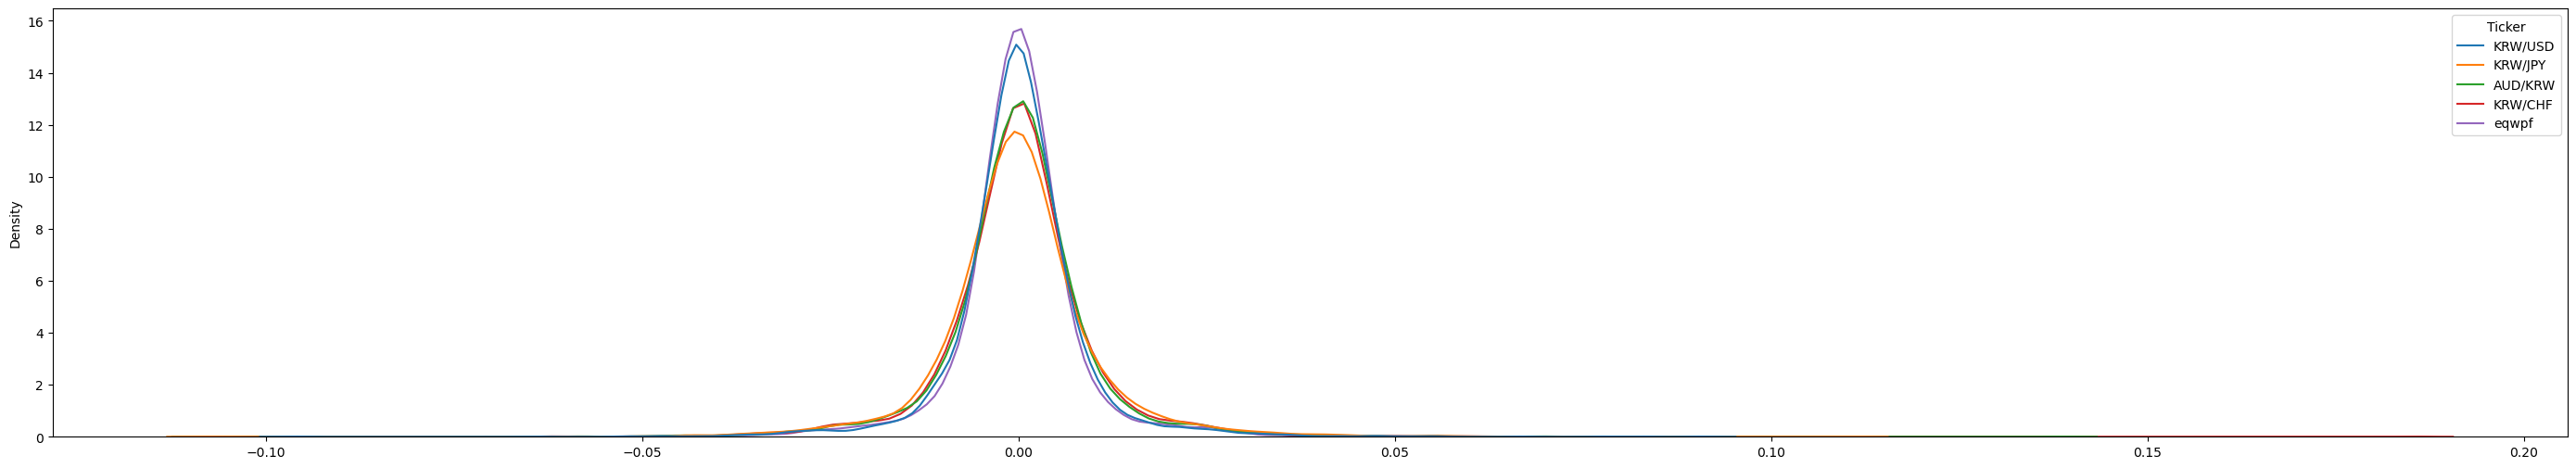

In [391]:
fig,ax = plt.subplots(figsize=(35, 6))
#sns.histplot(fx_krw_returns[invest_cols], kde=True, alpha=0.1, stat='density', line_kws={'lw':3}, ax=ax)
sns.kdeplot(fx_krw_returns[invest_cols], ax=ax);

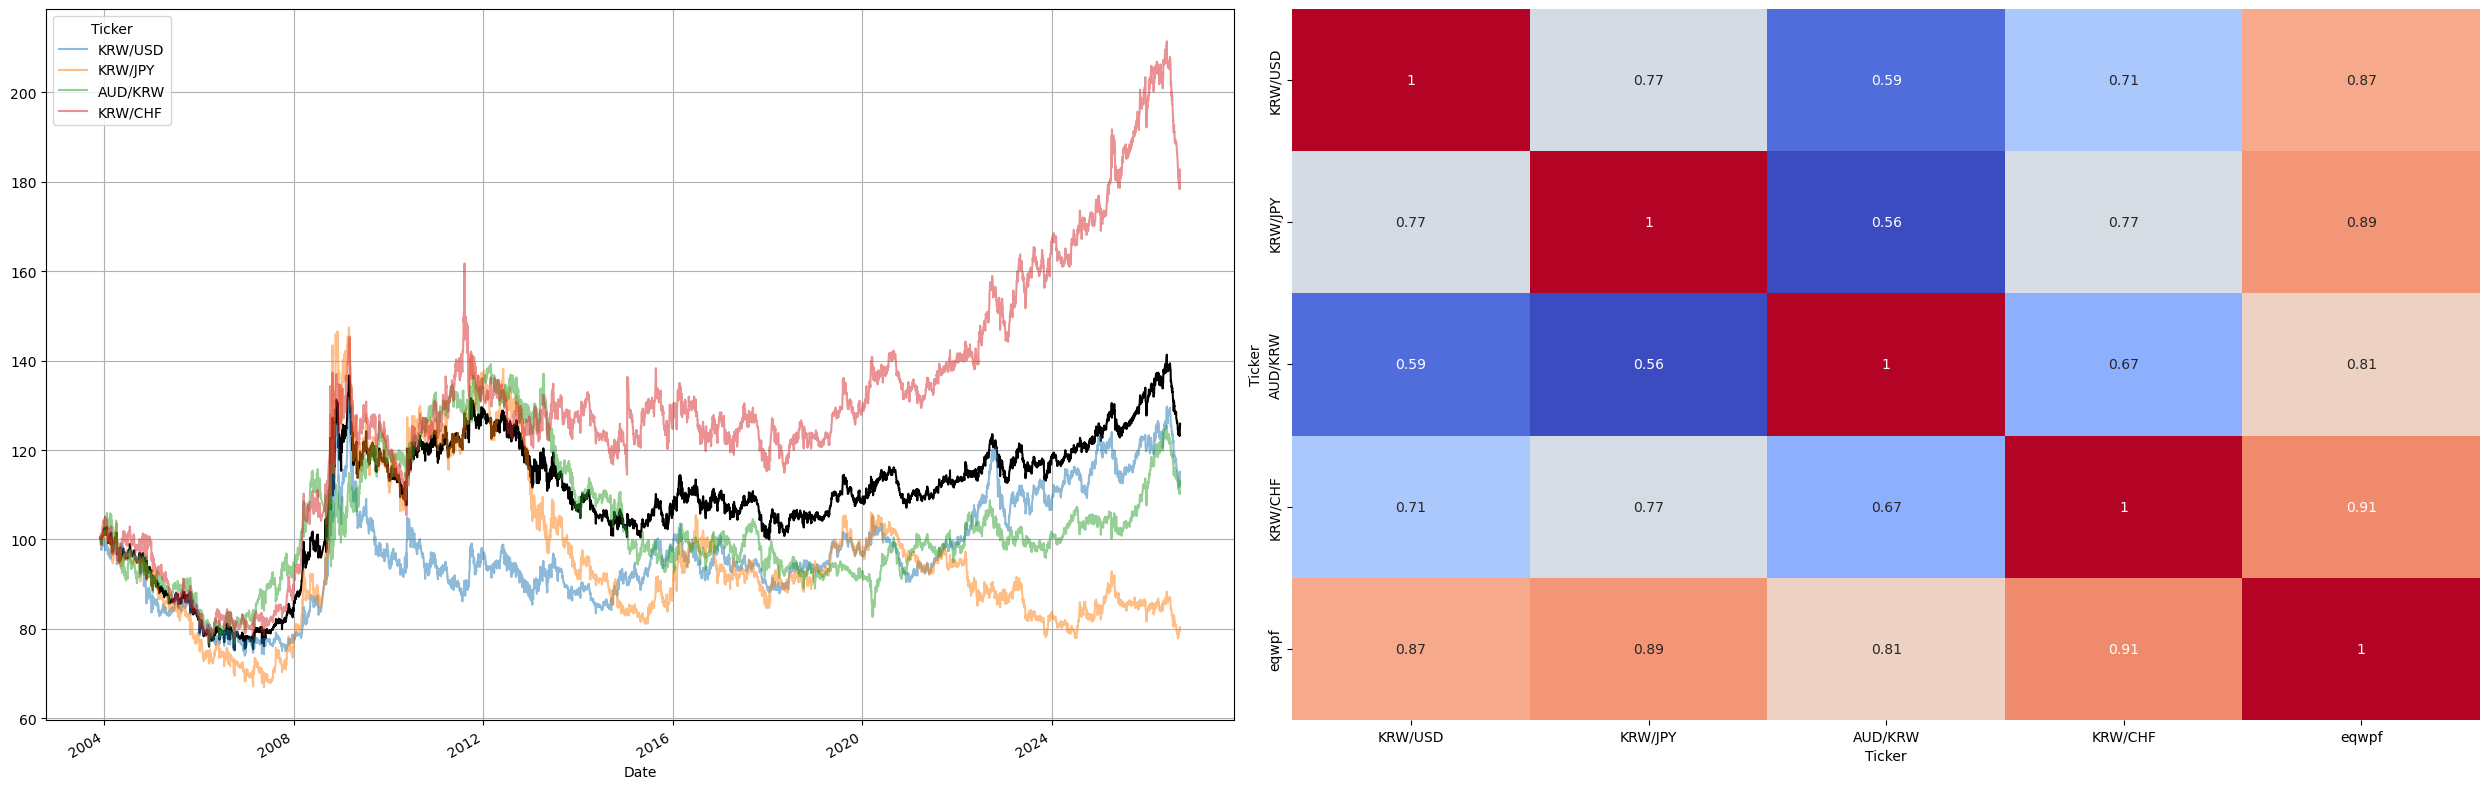

In [487]:
fig,ax = plt.subplots(1,2, figsize=(25, 8))
fx_krw_indices['eqwpf'].plot(ax=ax[0], c='black')
fx_krw_indices[label_list].plot(ax=ax[0], alpha=0.5)
ax[0].grid()

sns.heatmap(fx_krw_returns[invest_cols].corr(), cmap='coolwarm', annot=True, cbar=False, ax=ax[1])
plt.tight_layout();

rolling_360d_ret:


Ticker,KRW/USD,KRW/JPY,AUD/KRW,KRW/CHF,eqwpf
count,5552.000000,5552.000000,5552.000000,5552.000000,5552.000000
mean,0.023058,0.009494,0.015862,0.053521,0.027405
std,0.123090,0.202649,0.107073,0.138551,0.127508
min,-0.261887,-0.310021,-0.220611,-0.227368,-0.207229
25%,-0.052000,-0.105261,-0.061359,-0.031086,-0.045401
50%,0.000148,-0.031477,0.015016,0.031778,0.015975
75%,0.072599,0.070860,0.081160,0.113123,0.066736
max,0.687120,1.142400,0.430645,0.717203,0.678856


rolling_30d_ret:


Ticker,KRW/USD,KRW/JPY,AUD/KRW,KRW/CHF,eqwpf
count,5882.000000,5882.000000,5882.000000,5882.000000,5882.000000
mean,0.001367,-0.000284,0.000997,0.003588,0.001505
std,0.035205,0.043792,0.030264,0.034583,0.027920
min,-0.177052,-0.197417,-0.144789,-0.151339,-0.139552
25%,-0.018014,-0.023254,-0.018840,-0.018209,-0.014614
50%,0.000778,-0.004697,0.000661,0.002746,0.001282
75%,0.018219,0.017134,0.019813,0.021808,0.015550
max,0.334729,0.493737,0.171157,0.281802,0.275643


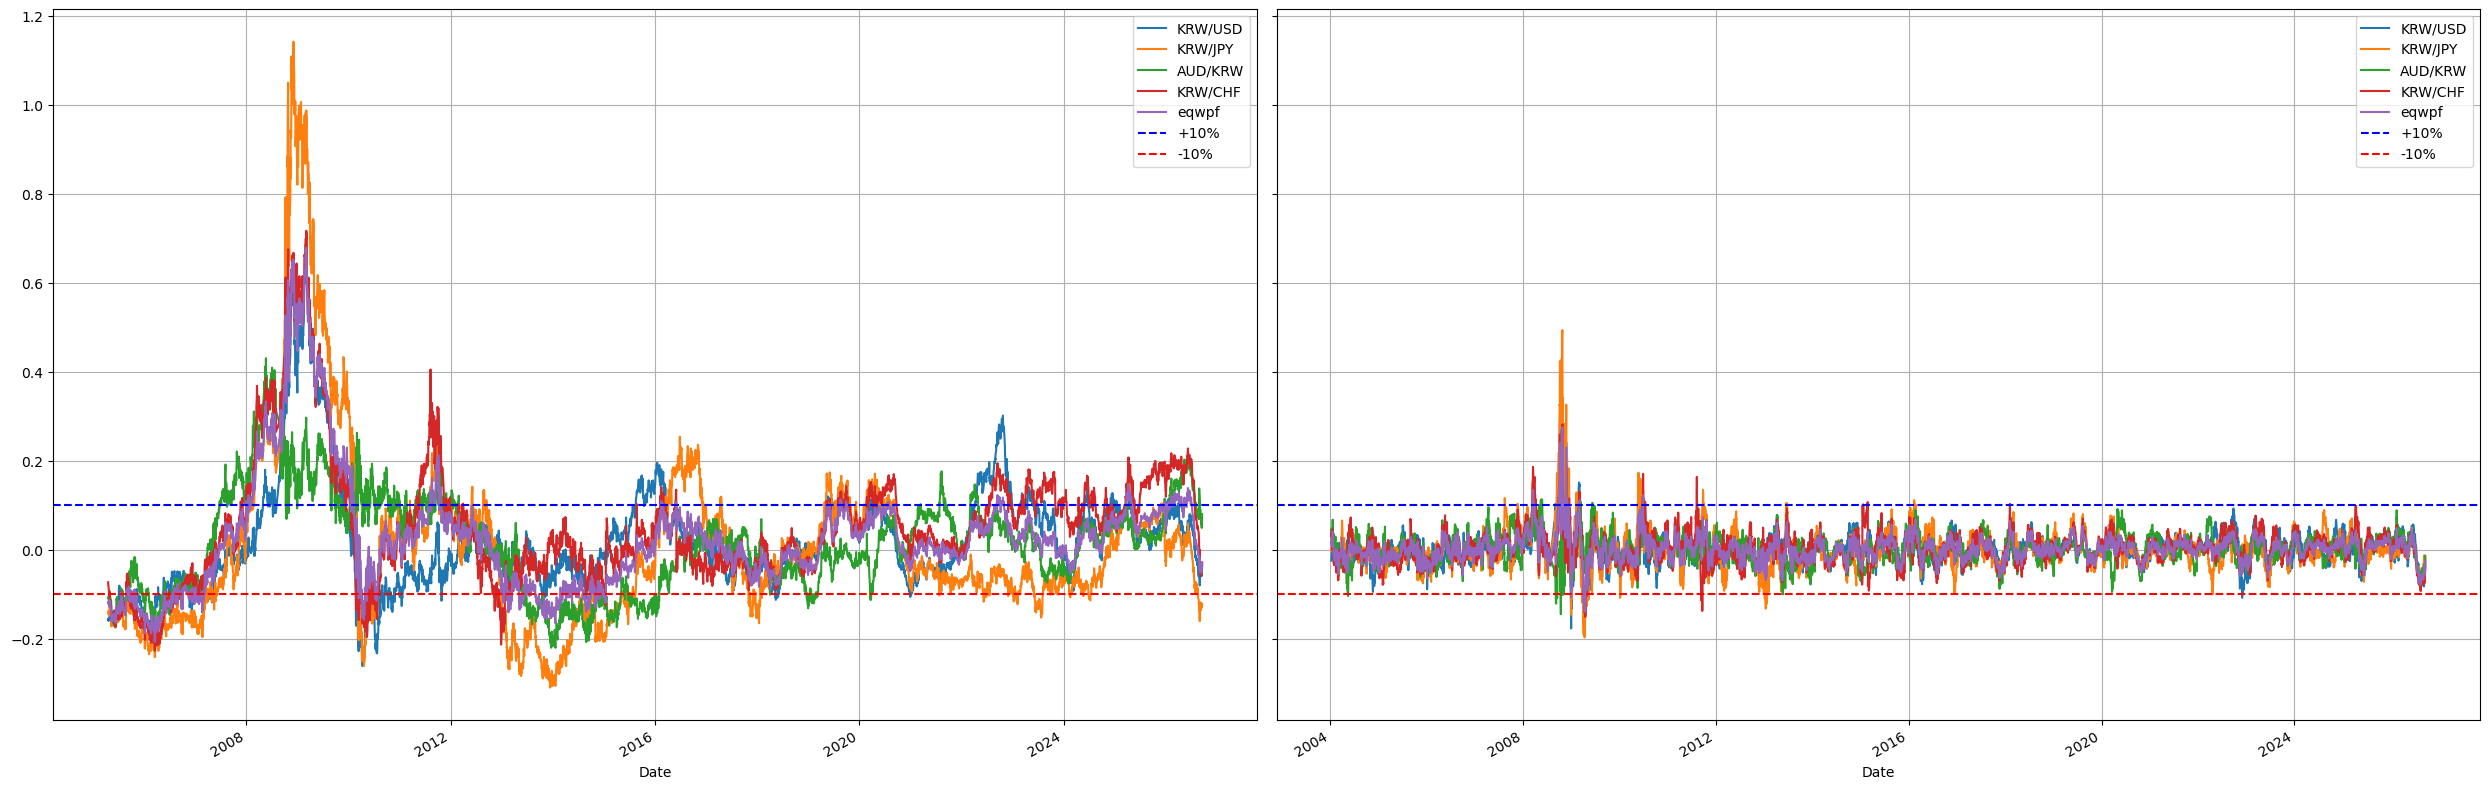

In [497]:
fig,ax = plt.subplots(1,2, figsize=(25, 8), sharey=True)

# rolling 360d returns
rolling_360d_ret = (
    (1 + fx_krw_returns[invest_cols])
    .rolling(window=360)
    .apply(np.prod) 
    - 1
)

# rolling 30d returns annualized
rolling_30d_ret = (
    (
        (1 + fx_krw_returns[invest_cols])
        .rolling(window=30)
        .apply(np.prod)
        - 1
    )
)

rolling_360d_ret.plot(ax=ax[0])
rolling_30d_ret.plot(ax=ax[1])

for i in range(len(ax)):
    ax[i].axhline(0.10, ls='--', c='blue', label='+10%')
    ax[i].axhline(-0.10, ls='--', c='red', label='-10%')
    ax[i].grid()
    ax[i].legend()
plt.tight_layout();

print('rolling_360d_ret:')
display(rolling_360d_ret.describe())
print('rolling_30d_ret:')
display(rolling_30d_ret.describe())

In [642]:
x = -0.055


percentile = (rolling_360d_ret.eqwpf.dropna() <= x).mean() * 100
# arr_sorted = np.sort(rolling_360d_ret.eqwpf.dropna())
# percentile = (np.searchsorted(arr_sorted, x, side='right') / len(arr_sorted)) * 100

print(f"PF Return of {x:.2%} is at the {percentile:.2f}th percentile of rolling_360d_ret.")
ß

percentile = (rolling_30d_ret.eqwpf.dropna() <= x).mean() * 100
# arr_sorted = np.sort(rolling_360d_ret.eqwpf.dropna())
# percentile = (np.searchsorted(arr_sorted, x, side='right') / len(arr_sorted)) * 100

print(f"PF Return of {x:.2%} is at the {percentile:.2f}th percentile of rolling_30d_ret.")

PF Return of -5.50% is at the 22.91th percentile of rolling_360d_ret.
PF Return of -5.50% is at the 1.22th percentile of rolling_30d_ret.


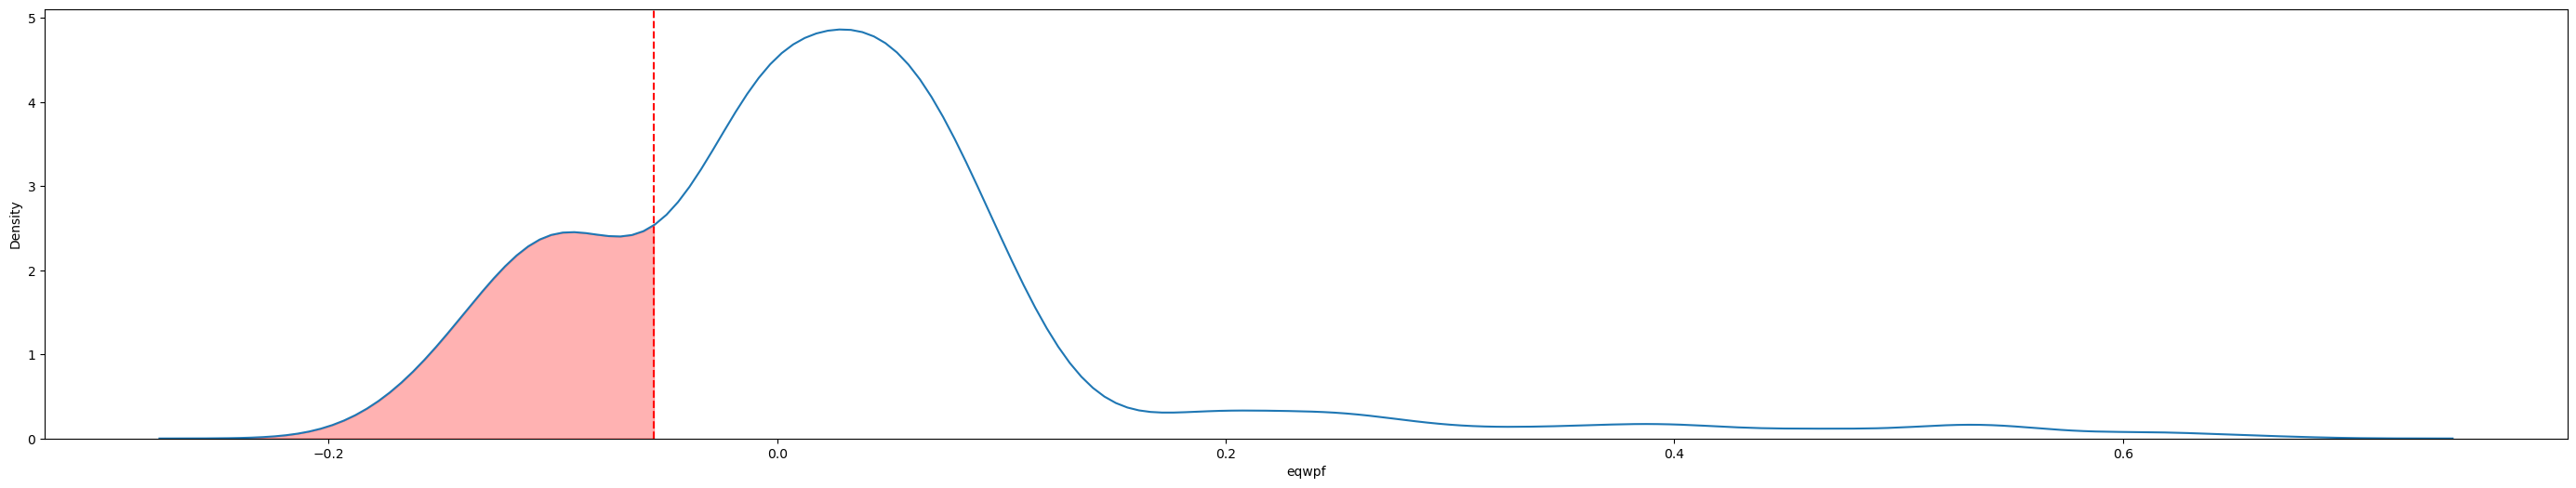

In [644]:
# fig, ax = plt.subplots(figsize=(35, 6))

# # 1. Plot KDE with Seaborn
# sns.kdeplot(rolling_360d_ret.eqwpf, ax=ax)

# # 2. Extract the line coordinates plotted for 'eqwpf'
# # (The last drawn line corresponds to 'eqwpf' as it's the last column in invest_cols)
# line = ax.lines[-1]
# x_data = line.get_xdata()
# y_data = line.get_ydata()

# # 3. Fill directly using the Seaborn curve data
# ax.fill_between(x_data, 0, y_data, where=(x_data <= x), color='red', alpha=0.3)
# ax.axvline(x, ls='--', c='red');

fig, ax = plt.subplots(figsize=(35, 6))

# 1. Plot KDE with Seaborn
sns.kdeplot(rolling_360d_ret.eqwpf, ax=ax)

# 2. Extract line coordinates
line = ax.lines[-1]
x_data = line.get_xdata()
y_data = line.get_ydata()

# 3. Interpolate y value exactly at x to close the gap
y_at_x = np.interp(x, x_data, y_data)

# Filter points strictly <= x and append the exact cutoff point (x, y_at_x)
mask = x_data <= x
x_fill = np.append(x_data[mask], x)
y_fill = np.append(y_data[mask], y_at_x)

# 4. Fill without gap
ax.fill_between(x_fill, 0, y_fill, color='red', alpha=0.3)
ax.axvline(x, ls='--', c='red');